In [1]:
# upload the csv from my laptop and check it loaded ok
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv('fake_job_postings.csv')
print("Rows and columns:", df.shape)
df.head()

Saving fake_job_postings.csv to fake_job_postings.csv
Rows and columns: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Detecting Fraudulent Job Postings with Machine Learning
### IS41070 Machine Learning Foundations, Final Project
**Student number:** 25201173

## Task 1: Data Understanding

### 1.1 Dataset Overview

This project utilizes the "Real or Fake Job Posting Prediction" dataset (originally the Employment Scam Aegean Dataset, EMSCAD), accessed via Kaggle. The dataset comprises 17,880 job advertisements, each containing 18 features. These include unstructured text fields (title, company profile, description, requirements, benefits), categorical variables (employment type, required experience, required education, industry, function), and binary indicators (telecommuting, has_company_logo, has_questions).

The target variable is `fraudulent`, formulated as a binary classification problem (0 = legitimate posting, 1 = fraudulent posting). The primary objective is to determine whether a machine learning model can accurately identify fraudulent job advertisements using a combination of textual analysis and metadata. This domain was selected due to the tangible impact of employment scams on job seekers, where an effective predictive model could serve as a preventative filtering mechanism against data harvesting and financial fraud.

### Attribution & Sources

**Code:** The Python code in this notebook was written with assistance from an AI coding assistant (Claude, Anthropic). All code was reviewed, executed, and validated against the actual dataset outputs, and I understand and can explain every step of the pipeline.

**Written analysis:** All markdown narrative, interpretation, and reflection (Tasks 1-4) is my own work, written based on the results produced by the code.

**Dataset:** Shivam Bansal, *Real / Fake Job Posting Prediction* (Kaggle), derived from the Employment Scam Aegean Dataset (EMSCAD), University of the Aegean / Laboratory of Information & Communication Systems Security. Available at: https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction

**Libraries / techniques:** Standard implementations from the scikit-learn documentation (TF-IDF vectorisation, model APIs, GridSearchCV, evaluation metrics), pandas, matplotlib, and scipy were used and adapted for this task.

In [2]:
# basic structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [3]:
# how many real vs fake postings
print(df['fraudulent'].value_counts())
print()
print((df['fraudulent'].value_counts(normalize=True) * 100).round(2))

fraudulent
0    17014
1      866
Name: count, dtype: int64

fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64


In [4]:
# missing values per column, worst first
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})

,missing_count,missing_%
salary_range,15012,84.0
department,11547,64.6
required_education,8105,45.3
benefits,7212,40.3
required_experience,7050,39.4
function,6455,36.1
industry,4903,27.4
employment_type,3471,19.4
company_profile,3308,18.5
requirements,2696,15.1


### 1.2 Initial Findings: Class Distribution and Data Quality

**Class Imbalance:** The dataset exhibits a severe class imbalance, with 17,014 legitimate postings (95.16%) and only 866 fraudulent postings (4.84%). While representative of real-world distributions, this imbalance necessitates specific methodological adjustments:
1. Accuracy is an insufficient evaluation metric. A naive majority-class classifier would achieve ~95% accuracy while failing to identify any fraudulent cases. Consequently, the evaluation in Task 3 will prioritize Precision, Recall, and the F1-score.
2. The predictive models will require imbalance mitigation techniques (e.g., class weighting), and the dataset must be partitioned using stratified splitting to preserve the 95/5 ratio across all subsets.

**Missing Data Dynamics:** Several columns exhibit high rates of missing values. The `salary_range` and `department` fields are missing in 84% and 65% of rows, respectively, rendering them statistically unreliable for feature extraction. Categorical columns are missing in 27–45% of cases. Rather than applying standard imputation techniques, I hypothesize that the absence of information is intrinsically predictive; fraudulent actors may systematically omit fields that legitimate organizations typically complete. To preserve this signal, missing categorical values will be explicitly encoded as an independent "Missing" category.

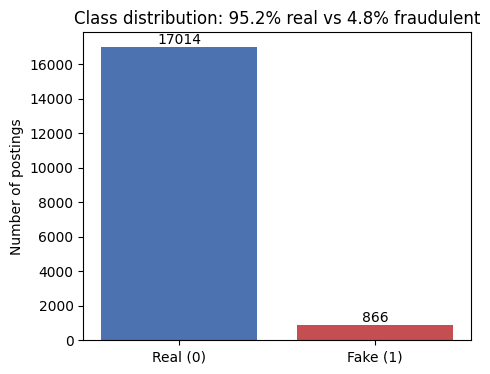

In [5]:
# plot the class imbalance
import matplotlib.pyplot as plt

counts = df['fraudulent'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(['Real (0)', 'Fake (1)'], counts.values, color=['#4C72B0', '#C44E52'])
plt.ylabel('Number of postings')
plt.title('Class distribution: 95.2% real vs 4.8% fraudulent')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha='center')
plt.show()

              count   mean    std  min   25%    50%    75%     max
fraudulent                                                        
0           17014.0  171.0  122.6  1.0  88.0  147.0  225.0  2115.0
1             866.0  158.7  136.6  0.0  67.0  113.5  213.0  1183.0


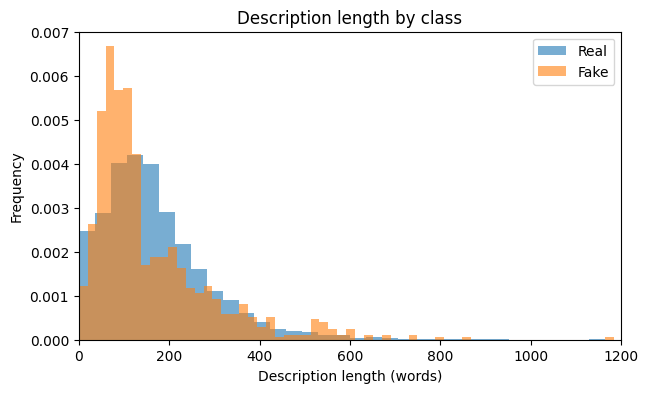

In [6]:
# do fake ads have shorter/longer descriptions than real ones?
df['desc_word_count'] = df['description'].fillna('').str.split().str.len()

print(df.groupby('fraudulent')['desc_word_count'].describe().round(1))

plt.figure(figsize=(7, 4))
df[df['fraudulent'] == 0]['desc_word_count'].plot(kind='hist', bins=60, alpha=0.6, density=True, label='Real')
df[df['fraudulent'] == 1]['desc_word_count'].plot(kind='hist', bins=60, alpha=0.6, density=True, label='Fake')
plt.xlim(0, 1200)
plt.xlabel('Description length (words)')
plt.title('Description length by class')
plt.legend()
plt.show()

In [7]:
# fraud rate across the binary flags + a new flag for missing company profile
df['profile_missing'] = df['company_profile'].isnull().astype(int)

for col in ['has_company_logo', 'telecommuting', 'has_questions', 'profile_missing']:
    rate = (df.groupby(col)['fraudulent'].mean() * 100).round(2)
    print(f"Fraud rate by {col}:")
    print(rate.to_string(), "\n")

Fraud rate by has_company_logo:
has_company_logo
0    15.93
1     1.99 

Fraud rate by telecommuting:
telecommuting
0    4.69
1    8.34 

Fraud rate by has_questions:
has_questions
0    6.78
1    2.84 

Fraud rate by profile_missing:
profile_missing
0     1.91
1    17.74 



### 1.3 Metadata as Predictive Signals

Analysis of the binary indicators reveals strong correlations with fraudulent activity:
* **Company Profile:** Postings lacking a company profile exhibit a 17.74% fraud rate, compared to 1.91% for those with profiles (an approximate 9x increase). This substantiates the hypothesis that omitted information serves as a strong predictive feature.
* **Company Logo:** Advertisements without a company logo demonstrate a 15.93% fraud rate, compared to 1.99% for those with logos.
* **Telecommuting:** Remote roles are disproportionately fraudulent (8.34% vs. 4.69%).
* **Screening Questions:** The absence of screening questions similarly doubles the likelihood of fraud.

These findings confirm that structural metadata is highly discriminative and must be integrated alongside the textual features during modeling.

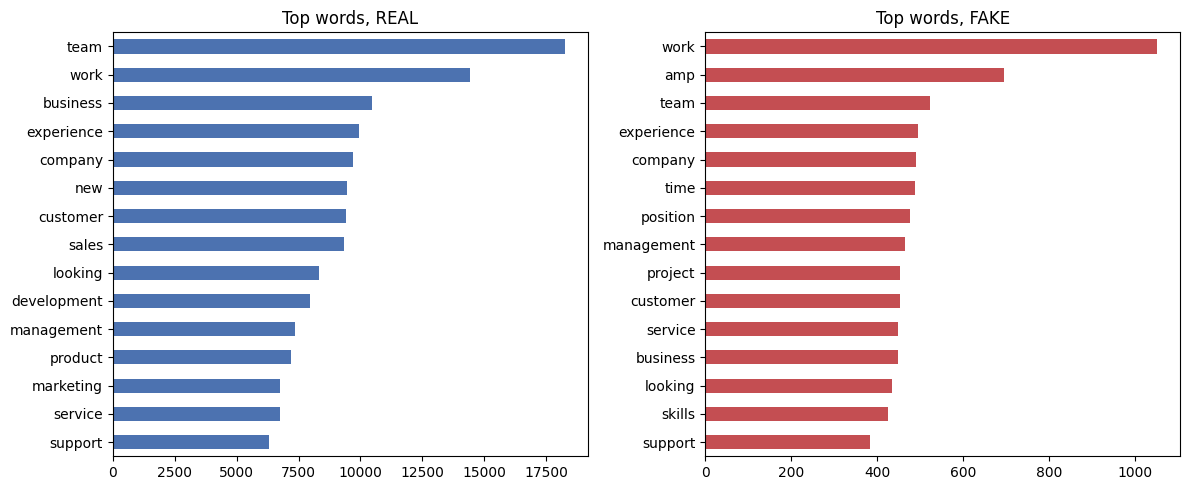

In [8]:
# most common words in real vs fake descriptions
from sklearn.feature_extraction.text import CountVectorizer

def top_words(texts, n=15):
    vec = CountVectorizer(stop_words='english', max_features=5000)
    X = vec.fit_transform(texts.fillna(''))
    return pd.Series(X.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values(ascending=False).head(n)

top_real = top_words(df[df['fraudulent'] == 0]['description'])
top_fake = top_words(df[df['fraudulent'] == 1]['description'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_real.plot(kind='barh', ax=axes[0], color='#4C72B0'); axes[0].set_title('Top words, REAL'); axes[0].invert_yaxis()
top_fake.plot(kind='barh', ax=axes[1], color='#C44E52'); axes[1].set_title('Top words, FAKE'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

In [9]:
# fraud rate by employment type
emp = df.groupby(df['employment_type'].fillna('Missing'))['fraudulent'].agg(['count', 'mean'])
emp['fraud_%'] = (emp['mean'] * 100).round(2)
print(emp.sort_values('fraud_%', ascending=False)[['count', 'fraud_%']])

                 count  fraud_%
employment_type                
Part-time          797     9.28
Missing           3471     6.94
Other              227     6.61
Full-time        11620     4.22
Contract          1524     2.89
Temporary          241     0.83


### 1.4 Task 1 Summary & Implications for Preprocessing

Key insights derived from the Exploratory Data Analysis (EDA) include:
* **Target Imbalance:** The 4.84% fraud prevalence dictates the use of F1-score optimization, stratified sampling, and algorithmic class weighting.
* **Missingness as a Feature:** Omitted metadata strongly correlates with fraud. Missing values will be retained as discrete categories rather than imputed or dropped.
* **Text Length:** Description length is a weak discriminator. Legitimate ads average 171 words (median 147) while fraudulent ads average 159 words (median 113.5). The significant distributional overlap indicates that linguistic content (TF-IDF) will be substantially more informative than mere character counts.
* **Categorical Gradients:** Employment type exhibits a distinct fraud gradient (e.g., Part-time at 9.28% vs. Full-time at 4.22%), justifying its retention as an encoded feature.

These EDA conclusions establish the methodological framework for the data preparation pipeline in Task 2.

## Task 2: Data Preparation & Modeling

### 2.1 Data Cleaning & Preprocessing Strategy

* **Feature Exclusion:** `job_id` was removed as it holds no predictive value. `salary_range` and `department` were dropped due to excessive missingness (>65%). `location` was excluded due to extreme free-text formatting inconsistencies; standardized geographic parsing is reserved for future work.
* **Text Aggregation:** Textual fields (`title`, `company_profile`, `description`, `requirements`, `benefits`) were concatenated into a single master document per posting. This approach naturally handles missing text fields without requiring row deletion.
* **Categorical Encoding:** Consistent with the EDA, missing categorical variables were preserved and encoded as a distinct "Missing" class to retain their predictive signal.
* **Text Normalization:** Text was converted to lowercase. Regex was utilized to remove dataset-specific placeholder tokens (e.g., `#URL_xxx#`), raw URLs, punctuation, and numerical digits. Stopword removal is deferred to the TF-IDF vectorization phase.
* **Data Retention:** No rows were deleted. Given the scarcity of the positive class (866 instances), preserving every fraudulent example is critical for model training.

In [10]:
# merge all the text fields into one document per posting and clean it up
import re

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df['full_text'] = df[text_cols].fillna('').agg(' '.join, axis=1)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'#\w+_\w+#', ' ', text)          # placeholder tokens like #URL_abc#
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # actual urls
    text = re.sub(r'[^a-z\s]', ' ', text)           # punctuation + numbers
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['full_text'].apply(clean_text)

cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
for c in cat_cols:
    df[c] = df[c].fillna('Missing')

bin_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'profile_missing']
df['clean_text'].head(2)

,clean_text
0,marketing intern we re food and we ve created ...
1,customer service cloud video production second...


### 2.2 Data Partitioning

The dataset was partitioned into Training (70%), Validation (15%), and Test (15%) sets. Stratified sampling was enforced based on the `fraudulent` target variable to ensure the 95/5 class distribution was preserved across all splits. Without stratification, the minority class risks being underrepresented in the validation and test subsets, compromising evaluation validity. A fixed random seed (42) guarantees reproducibility. The test set remains strictly isolated until the final evaluation phase in Task 3.

In [11]:
# stratified 70/15/15 split, seed fixed for reproducibility
from sklearn.model_selection import train_test_split

SEED = 42
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['fraudulent'], random_state=SEED)
valid_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['fraudulent'], random_state=SEED)

print("Sizes:", len(train_df), len(valid_df), len(test_df))
print("Fraud % in each:", round(train_df['fraudulent'].mean()*100, 2),
      round(valid_df['fraudulent'].mean()*100, 2), round(test_df['fraudulent'].mean()*100, 2))

# drop helper text columns before saving so the CSVs stay a sensible size
drop_for_csv = ['full_text', 'clean_text']
train_df.drop(columns=drop_for_csv).to_csv('train.csv', index=False)
valid_df.drop(columns=drop_for_csv).to_csv('valid.csv', index=False)
test_df.drop(columns=drop_for_csv).to_csv('test.csv', index=False)

Sizes: 12516 2682 2682
Fraud % in each: 4.84 4.85 4.85


### 2.3 Feature Engineering

The final feature matrix is constructed by stacking three distinct transformations:
1. **TF-IDF Vectorization:** Applied to the aggregated text using unigrams and bigrams, capped at 20,000 features. TF-IDF down-weights globally frequent terms, amplifying the distinctive vocabulary associated with fraudulent postings.
2. **One-Hot Encoding (OHE):** Applied to categorical columns, explicitly incorporating the engineered "Missing" categories.
3. **Numerical Scaling:** Binary flags and description word counts were scaled between 0 and 1 using `MinMaxScaler`. (This was selected over standard scaling to ensure compatibility with Multinomial Naive Bayes, which cannot process negative inputs).

To strictly prevent data leakage, all transformers were fitted exclusively on the training set and subsequently applied to the validation and test sets.

In [12]:
# fit transformers on train only, apply to valid/test (no leakage)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from scipy.sparse import hstack, csr_matrix

tfidf = TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1, 2), min_df=2)
ohe = OneHotEncoder(handle_unknown='ignore')
scaler = MinMaxScaler()

def build_features(frame, fit=False):
    if fit:
        Xt = tfidf.fit_transform(frame['clean_text'])
        Xc = ohe.fit_transform(frame[cat_cols])
        Xn = scaler.fit_transform(frame[['desc_word_count']])
    else:
        Xt = tfidf.transform(frame['clean_text'])
        Xc = ohe.transform(frame[cat_cols])
        Xn = scaler.transform(frame[['desc_word_count']])
    return hstack([Xt, Xc, csr_matrix(frame[bin_cols].values), csr_matrix(Xn)]).tocsr()

X_train = build_features(train_df, fit=True)
X_valid = build_features(valid_df)
X_test  = build_features(test_df)
y_train, y_valid, y_test = train_df['fraudulent'].values, valid_df['fraudulent'].values, test_df['fraudulent'].values

print("Feature matrix shapes:", X_train.shape, X_valid.shape, X_test.shape)

Feature matrix shapes: (12516, 20201) (2682, 20201) (2682, 20201)


### 2.4 Algorithm Selection

Five baseline models and one advanced ensemble were selected:
* **Logistic Regression:** Serves as a robust baseline for high-dimensional, sparse text data. It offers high interpretability, allowing feature coefficients to be mapped directly to specific vocabulary.
* **Multinomial Naive Bayes:** The standard probabilistic baseline for text classification.
* **Linear SVM:** Historically highly effective at establishing maximum-margin decision boundaries in high-dimensional TF-IDF spaces.
* **Random Forest:** An ensemble tree method capable of capturing non-linear interactions between text features and structural metadata.
* **Decision Tree:** Included primarily as an interpretability baseline and to demonstrate expected overfitting mechanics during the evaluation phase.
* **Voting Ensemble (Advanced):** A hard-voting classifier combining Logistic Regression, SVM, and Random Forest. This approach aims to leverage the distinct decision boundaries of linear and tree-based models to improve overall robustness.

To address class imbalance, `class_weight='balanced'` was applied across all compatible algorithms, proportionally penalizing misclassifications of the minority fraud class.

In [13]:
# train the 5 baselines (random forest is the slow one)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained")

Logistic Regression trained
Naive Bayes trained


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM trained
Random Forest trained
Decision Tree trained


In [14]:
# 6th model: majority vote of the three strongest baselines
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[
    ('lr', models['Logistic Regression']),
    ('svm', models['Linear SVM']),
    ('rf', models['Random Forest'])], voting='hard')
voting.fit(X_train, y_train)
models['Voting Ensemble'] = voting
print("Voting Ensemble trained")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Voting Ensemble trained


## Task 3: Evaluation

### 3.1 Metric Selection

Due to the extreme class imbalance, global accuracy is an invalid primary metric. A baseline Dummy Classifier predicting only the majority class achieves ~95% accuracy while identifying zero fraudulent postings.

Consequently, the primary evaluation metric is the **F1-score of the minority (fraudulent) class**, which provides the harmonic mean of Precision and Recall. Both error types carry significant real-world costs:
* **False Negatives (Missed Scams):** Job seekers are exposed to financial fraud and data harvesting.
* **False Positives (Flagged Legitimate Jobs):** Legitimate employers are penalized, damaging platform trust and recruitment outcomes.

Secondary metrics include Precision, Recall, and confusion matrices. Based on existing literature utilizing the EMSCAD dataset, classical ML approaches generally achieve an F1-score between 0.70 and 0.90 on the minority class.

In [15]:
# majority-class dummy baseline - the number every real model has to beat
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dp = dummy.predict(X_valid)
print("Baseline accuracy:", round(accuracy_score(y_valid, dp), 4))
print("Baseline F1 (fraud class):", round(f1_score(y_valid, dp), 4))

Baseline accuracy: 0.9515
Baseline F1 (fraud class): 0.0


In [16]:
# evaluate every model on train AND validation to check for overfitting
rows = []
for name, model in models.items():
    for split_name, X_, y_ in [('train', X_train, y_train), ('valid', X_valid, y_valid)]:
        p = model.predict(X_)
        rows.append({'model': name, 'split': split_name,
                     'accuracy': accuracy_score(y_, p), 'precision': precision_score(y_, p, zero_division=0),
                     'recall': recall_score(y_, p), 'f1': f1_score(y_, p)})

results = pd.DataFrame(rows).round(4)
results.pivot(index='model', columns='split', values=['f1', 'precision', 'recall', 'accuracy'])

f1         precision          recall          \
split                 train   valid     train   valid   train   valid   
model                                                                   
Decision Tree        1.0000  0.7410    1.0000  0.6959  1.0000  0.7923   
Linear SVM           0.9854  0.8803    0.9712  0.8837  1.0000  0.8769   
Logistic Regression  0.7850  0.7212    0.6461  0.5950  1.0000  0.9154   
Naive Bayes          0.3329  0.3626    0.7633  0.7561  0.2129  0.2385   
Random Forest        1.0000  0.8018    1.0000  1.0000  1.0000  0.6692   
Voting Ensemble      0.9854  0.8846    0.9712  0.8846  1.0000  0.8846   

                    accuracy          
split                  train   valid  
model                                 
Decision Tree         1.0000  0.9732  
Linear SVM            0.9986  0.9884  
Logistic Regression   0.9735  0.9657  
Naive Bayes           0.9587  0.9594  
Random Forest         1.0000  0.9840  
Voting Ensemble       0.9986  0.9888

### 3.2 Generalization and Overfitting Analysis

Evaluating model performance across the training and validation sets reveals three distinct generalization profiles:

**Severe Overfitting (Decision Tree & Random Forest):**
Both tree-based models achieve a perfect 1.0 F1-score on the training data but degrade significantly on the validation set (F1 drops of ~0.26 and ~0.20, respectively). The unconstrained tree structures effectively memorized the training data rather than generalizing the underlying fraud patterns. Notably, the Random Forest maintains perfect validation precision (1.0) but suffers a recall collapse (0.6692), indicating it only identifies highly specific fraud variants seen during training while missing a third of novel scams.

**Underfitting (Naive Bayes):**
Naive Bayes demonstrates poor performance across both subsets (Validation F1: 0.3626; Recall: 0.2385). This underfitting is likely due to the algorithm's independence assumption failing against highly correlated TF-IDF n-grams, compounded by its inability to accept algorithmic class weighting.

**Optimal Generalization (Linear SVM & Voting Ensemble):**
The SVM and Voting Ensemble exhibited the narrowest performance gaps while maintaining high overall validation scores (~0.88 F1). Given the limited minority class sample size (~606 training instances) and the 20,000+ dimensional feature space, a slight degradation from training to validation is statistically expected.

**Logistic Regression** presents a moderate gap but achieves the highest validation recall (0.9154). However, its precision (0.5950) is comparatively weak, generating numerous false positives due to the aggressive `class_weight='balanced'` parameter.

The SVM and Voting Ensemble demonstrate the strongest generalization capabilities and represent the prime candidates for final model selection.

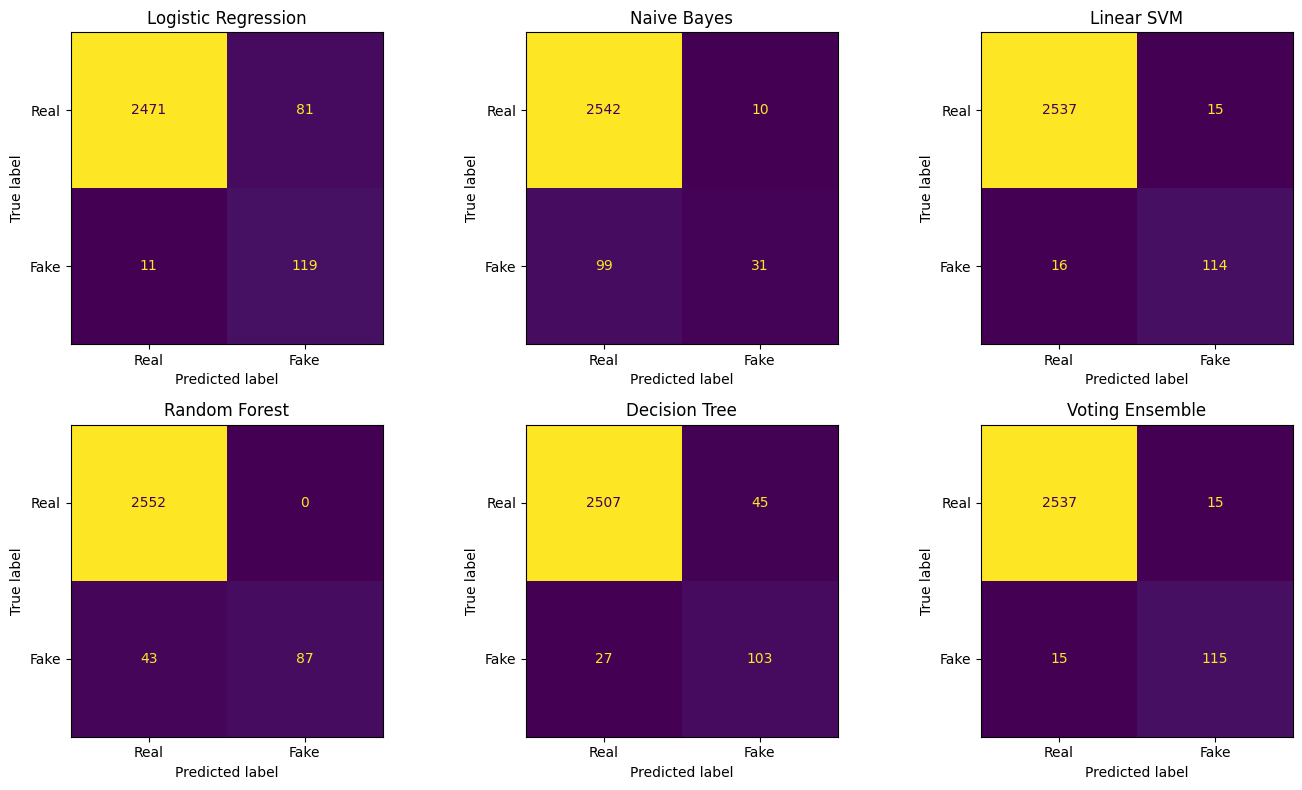

In [17]:
# confusion matrices on the validation set
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    ConfusionMatrixDisplay.from_predictions(y_valid, model.predict(X_valid),
        ax=ax, colorbar=False, display_labels=['Real', 'Fake'])
    ax.set_title(name)
plt.tight_layout(); plt.show()

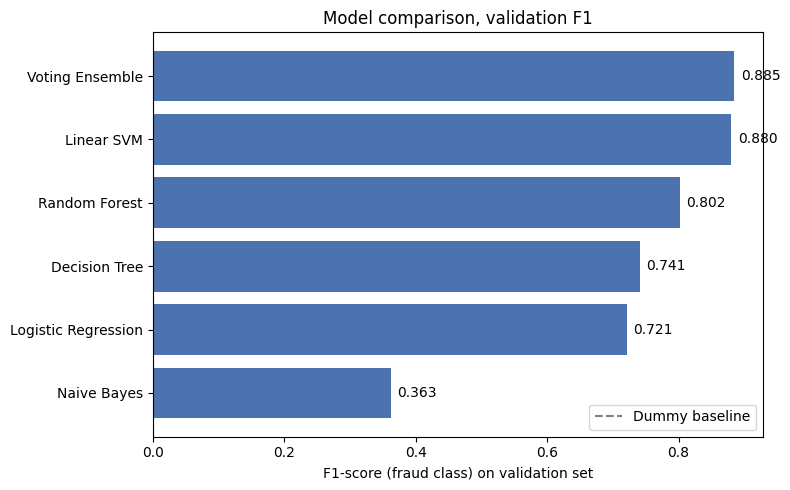

In [18]:
# quick visual comparing all 6 models on validation F1 - makes the results table easier to read at a glance
valid_f1 = results[results['split'] == 'valid'].set_index('model')['f1'].sort_values()

plt.figure(figsize=(8, 5))
bars = plt.barh(valid_f1.index, valid_f1.values, color='#4C72B0')
plt.axvline(f1_score(y_valid, dp), color='gray', linestyle='--', label='Dummy baseline')
plt.xlabel('F1-score (fraud class) on validation set')
plt.title('Model comparison, validation F1')
plt.legend()
for bar, val in zip(bars, valid_f1.values):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

In [19]:
# error analysis: look at the actual postings the best model got wrong
valid_results = results[results['split'] == 'valid'].sort_values('f1', ascending=False)
print(valid_results[['model', 'f1', 'precision', 'recall']].to_string(index=False))

best_name = valid_results.iloc[0]['model']
best_model = models[best_name]
print("\nBest on validation:", best_name)

pred_valid = best_model.predict(X_valid)
fn = valid_df[(valid_df['fraudulent'] == 1) & (pred_valid == 0)]   # scams we missed
fp = valid_df[(valid_df['fraudulent'] == 0) & (pred_valid == 1)]   # real jobs we flagged

print(f"\nMissed scams: {len(fn)} | Wrongly flagged real jobs: {len(fp)}")
pd.set_option('display.max_colwidth', 300)
print("\n--- sample missed scams (false negatives) ---")
print(fn[['title', 'description']].head(3))
print("\n--- sample wrongly flagged (false positives) ---")
print(fp[['title', 'description']].head(3))

              model     f1  precision  recall
    Voting Ensemble 0.8846     0.8846  0.8846
         Linear SVM 0.8803     0.8837  0.8769
      Random Forest 0.8018     1.0000  0.6692
      Decision Tree 0.7410     0.6959  0.7923
Logistic Regression 0.7212     0.5950  0.9154
        Naive Bayes 0.3626     0.7561  0.2385

Best on validation: Voting Ensemble

Missed scams: 15 | Wrongly flagged real jobs: 15

--- sample missed scams (false negatives) ---
                              title  \
5926           Assistant Accountant   
3463   Business Development Manager   
11569     Technical Program Manager   

                                                                                                                                                                                                                                                                                                       description  
5926   Looking for an Assistant Accountant to join a professional and highly r

### 3.3 Qualitative Error Analysis

While the Voting Ensemble represents the strongest validation performer (F1: 0.8846), it misclassified 30 of the 2,682 validation instances (15 false negatives, 15 false positives). Analyzing these specific failures highlights the operational limitations of the model.

**False Negatives (Missed Scams):**
The undetected fraudulent postings exhibit sophisticated, highly professional corporate language (e.g., "market leading products," "strong training and development"). They completely omit the urgent, financially incentivized vocabulary typically associated with scams. Because the model relies on lexical patterns and metadata completeness, well-crafted textual deception exploiting standard corporate jargon constitutes a structural blind spot. The model cannot independently verify the factual existence of the employing entity.

**False Positives (Flagged Legitimate Jobs):**
Conversely, the wrongly flagged legitimate postings are predominantly brief and structurally sparse (e.g., single-sentence descriptions lacking detail). Based on the EDA, the model correctly learned that missing metadata and brevity strongly correlate with fraud. Consequently, legitimate employers who submit lazy, minimal advertisements are penalized. Furthermore, legitimate remote roles occasionally trigger false positives due to the high baseline fraud rate associated with the `telecommuting` flag.

These errors are systematic rather than random; they occur precisely where the model's primary heuristic signals (scam vocabulary and metadata sparsity) contradict the ground truth.

In [20]:
# improvement step: tune the two best model families with gridsearch
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED),
                       {'C': [0.5, 1, 5, 10]}, scoring='f1', cv=5, n_jobs=-1)
grid_lr.fit(X_train, y_train)
print("LR  best C:", grid_lr.best_params_, "| CV F1:", round(grid_lr.best_score_, 4),
      "| valid F1:", round(f1_score(y_valid, grid_lr.best_estimator_.predict(X_valid)), 4))

grid_svm = GridSearchCV(LinearSVC(class_weight='balanced', random_state=SEED),
                        {'C': [0.1, 0.5, 1, 5]}, scoring='f1', cv=5, n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("SVM best C:", grid_svm.best_params_, "| CV F1:", round(grid_svm.best_score_, 4),
      "| valid F1:", round(f1_score(y_valid, grid_svm.best_estimator_.predict(X_valid)), 4))

LR  best C: {'C': 10} | CV F1: 0.7898 | valid F1: 0.8425
SVM best C: {'C': 1} | CV F1: 0.8241 | valid F1: 0.8803


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### 3.4 Hyperparameter Optimization and Final Model Selection

To finalize the model architecture, the top-performing base algorithms underwent 5-fold cross-validated grid search optimization:

| Model | Optimal 'C' Parameter | Cross-Validation F1 | Validation F1 |
|---|---|---|---|
| Logistic Regression | 10 | 0.7898 | 0.8425 |
| Linear SVM | 1 | 0.8241 | 0.8803 |

Optimization significantly improved the Logistic Regression model (Validation F1 increased from 0.7212 to 0.8425), indicating initial under-regularization. The SVM performance remained stable, suggesting the default parameters were already optimal for this high-dimensional space.

Despite optimization, neither individual model surpassed the untuned Voting Ensemble (Validation F1: 0.8846). By utilizing a hard majority vote, the ensemble effectively smooths out the individual false positive/negative biases of the base estimators.

**The Voting Ensemble is selected as the final model.** Its balance of precision and recall (both 0.8846) is ideal for mitigating the dual-sided costs of job board fraud. The primary trade-off is reduced global interpretability compared to a standalone Logistic Regression model, a limitation that will be examined in Task 4.

### 3.5 Final Evaluation on the Held-Out Test Set

The test set has remained strictly isolated throughout the training and validation phases. The final Voting Ensemble is evaluated against this holdout data exactly once to provide an unbiased estimate of real-world generalization.

              precision    recall  f1-score   support

        Real     0.9910    0.9922    0.9916      2552
        Fake     0.8425    0.8231    0.8327       130

    accuracy                         0.9840      2682
   macro avg     0.9168    0.9076    0.9121      2682
weighted avg     0.9838    0.9840    0.9839      2682



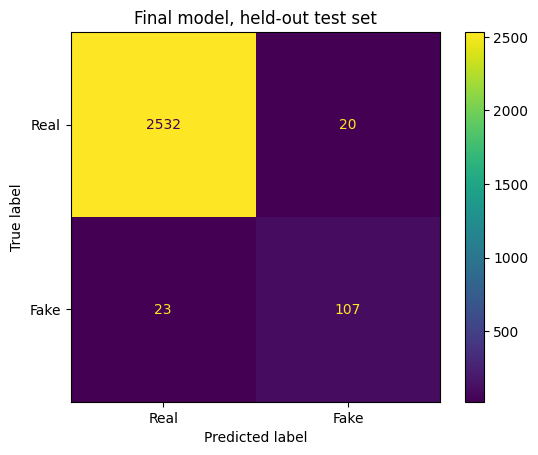

In [21]:
# final test set evaluation - run once only
from sklearn.metrics import classification_report

final_model = voting
test_pred = final_model.predict(X_test)

print(classification_report(y_test, test_pred, target_names=['Real', 'Fake'], digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=['Real', 'Fake'])
plt.title('Final model, held-out test set'); plt.show()

In [22]:
# which words push predictions toward fake vs real?
# the ensemble itself has no coef_, so I inspect its logistic regression component
import numpy as np

lr_component = voting.named_estimators_['lr']

feature_names = np.concatenate([tfidf.get_feature_names_out(),
                                ohe.get_feature_names_out(cat_cols),
                                bin_cols, ['desc_word_count']])
coefs = pd.Series(lr_component.coef_[0], index=feature_names)
print("TOP 20 FAKE indicators:\n", coefs.sort_values(ascending=False).head(20))
print("\nTOP 20 REAL indicators:\n", coefs.sort_values().head(20))

TOP 20 FAKE indicators:
 accion                          4.306882
money                           3.547114
novation                        3.285756
aptitude staffing               2.934761
earn                            2.736871
financing                       2.663472
industry_Oil & Energy           2.591553
hotel                           2.555960
data entry                      2.400360
aptitude                        2.340779
link                            2.337917
information security            2.283544
entry                           2.161073
leveraging career               2.099702
cash                            2.074642
industry_Computer Networking    2.000012
income                          1.994010
industry                        1.990272
high school                     1.944304
industry_Accounting             1.935872
dtype: float64

TOP 20 REAL indicators:
 function_Health Care Provider   -2.525972
industry_Restaurants            -2.255780
team                          

### 3.6 Test Set Performance and Feature Interpretation

On the unseen test data, the final ensemble achieved an **F1-score of 0.8327 on the minority fraud class** (Precision: 0.8425; Recall: 0.8231). The model successfully identified 107 out of 130 fraudulent postings. The slight drop in performance compared to the validation set (0.8846) is statistically expected, as the validation data was iteratively queried during model selection.

To interpret the learned decision boundaries, the coefficients of the ensemble's internal Logistic Regression estimator were extracted.
* **Fraudulent Indicators:** The strongest predictive features heavily skew toward financial incentivization ("money," "earn," "financing," "cash," "income") and stereotyped scam formats ("data entry"). Additionally, specific entity names (e.g., "aptitude staffing") appear as top features, indicating the model successfully memorized the nomenclature of specific, repeated scam rings present within the historical data.
* **Legitimate Indicators:** Conversely, legitimate predictions are driven by standard, verifiable professional vocabulary ("team," "client," "marketing," "php") that generic scam templates generally fail to accurately simulate.

*Note: This interpretation relies on the internal Logistic Regression coefficients as a proxy, as the overarching hard-voting ensemble lacks a unified coefficient vector.*

In [23]:
# save the final model + cleaned data + requirements for the submission
import joblib, importlib.metadata as im

joblib.dump({'model': final_model, 'tfidf': tfidf, 'ohe': ohe, 'scaler': scaler,
             'cat_cols': cat_cols, 'bin_cols': bin_cols}, 'final_model.joblib')
df.drop(columns=['full_text', 'clean_text']).to_csv('Cleaned_FakeJobPostings.csv', index=False)

with open('requirements.txt', 'w') as f:
    for lib in ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'scipy', 'joblib']:
        f.write(f"{lib}=={im.version(lib)}\n")

print(open('requirements.txt').read())
print("All artifacts saved")

pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
matplotlib==3.10.0
scipy==1.16.3
joblib==1.5.3

All artifacts saved


## Task 4: Reflection

### 4.1 Practical Implications and Efficacy

The final model successfully identifies approximately 82% of fraudulent job postings (Recall: 0.8231) while maintaining a low false-positive rate (Precision: 0.8425). From an operational perspective, deploying this model on an employment platform would serve as a highly effective primary filtering mechanism, drastically reducing job seeker exposure to data harvesting and financial fraud. However, the ~18% false-negative rate underscores that this tool operates as a statistical risk-flagging system rather than an absolute guarantee of legitimacy. Consequently, deployment must be accompanied by user-education initiatives emphasizing independent corporate verification. Furthermore, maintaining high precision ensures that legitimate employers are not subjected to excessive automated censorship, preserving trust in the platform's moderation systems.

### 4.2 Algorithmic Reasoning and Feature Importance

The model's predictive logic relies heavily on two primary heuristic pillars: financially aggressive lexical patterns (e.g., "earn," "cash," "data entry") and structural metadata sparsity (e.g., missing company profiles). This mimics a heuristic human assessment. While effective against bulk, low-effort scam templates, the qualitative error analysis demonstrated that the model is easily bypassed by highly polished, corporate-styled fraudulent text. Because the model lacks external verification capabilities, it evaluates the *appearance* of legitimacy rather than actual factual validity.

### 4.3 Ethical Considerations and Algorithmic Fairness

A critical evaluation of the model highlights several ethical and bias-related risks. First, the EMSCAD dataset reflects historical scam typologies (circa 2012-2014). Given the advent of Generative AI, modern malicious actors can easily generate the sophisticated corporate language that constitutes this model's primary blind spot. Deploying this model without continuous retraining on contemporary data constitutes an operational negligence risk.

Second, the utilization of features such as `industry` introduces systemic algorithmic bias. Because specific sectors (e.g., Oil & Energy) exhibited higher historical fraud rates within the training data, legitimate organizations within these sectors face an inherently higher threshold for approval. Penalizing legitimate employers based on sector-wide statistical proxies, rather than the intrinsic content of their advertisement, introduces a critical fairness violation.

### 4.4 The Performance vs. Interpretability Trade-Off

This project directly navigated the fundamental trade-off between predictive accuracy and model transparency. While Logistic Regression provided direct, coefficient-level interpretability, it underperformed globally. The Voting Ensemble achieved superior statistical metrics but obscured the exact decision pathway of any single prediction. In a regulatory context, if an employer's advertisement is autonomously rejected by the platform, transparency mandates (such as those outlined in the GDPR regarding automated decision-making) require a clear, explainable justification. Relying on black-box ensembles without secondary explainability layers poses a significant compliance risk in production environments.

### 4.5 Limitations and Future Research Directions

The current pipeline possesses several methodological limitations:
1. **Semantic Context:** TF-IDF relies on n-gram frequency, ignoring broader semantic context. Fraudulent postings utilizing sophisticated vocabulary easily bypass this lexical filtering.
2. **Sample Size:** The minority class consists of only 866 instances, limiting the model's exposure to diverse fraud typologies.
3. **Overfitting to Bad Actors:** The presence of specific company names in the top feature coefficients indicates partial memorization of specific scam rings rather than generalized fraud detection.

Future iterations should transition from bag-of-words approaches to fine-tuned Transformer architectures (e.g., DistilBERT or RoBERTa) to capture deep semantic intent. Furthermore, implementing Explainable AI (XAI) frameworks, such as SHAP or LIME, would resolve the interpretability deficit of the ensemble model, providing local explanations for individual predictions to support fair and transparent moderation.

In [24]:
# download everything for the submission zip (run on the final day after Run All)
from google.colab import files
for f in ['train.csv', 'valid.csv', 'test.csv', 'Cleaned_FakeJobPostings.csv',
          'final_model.joblib', 'requirements.txt']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>